## What the task is about...
This is a machine learning activity intended to mining sentiment from a tweeter dataset.
The process for moving from data loading, inspection, to machine learning model creation, training and prediction is exactly as we have come to see.

### What might be different
- We will have to rid the tweeter data of special characters not useful to a ML model
- We will have to convert our tweets into a format ingestible by a ML model
- We will discover and apply some NLP techniques just before building our model

## The ML algorithm that we will use
- a RandomForest classifier

## What the task is really about:
- classififying a tweet as either Positive, Negative, or Neutral.
- the tweeks a reviews of some airlines in the USA.

## Dataset
- Use the provided Tweets.csv file

## Task 1 - import relevant libraries
- you will need at least numpy, matplotlib, nltk, re and pandas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nltk
import pandas as pd

## Task 2 - Load the Tweets.csv data in memory using pandas
- give your dataframe a suitable name e.g., <em>airlines</em>

## Task 3 - Take a look at the first 5 records
- try to comprehend what some of the columns are about
### Questions to consider:
- which feature/column is contains the sentiment/opinion?
- which feature/column contains the tweet?
- which feature/column contains the airline name?
### Task 3.1 - reviewing the features
- List the first 10 values of the sentiment feature
- List the last 10 values of the tweet feature
- list the unique names of the airlines in the dataset


<b>Feel free to add further code cells if you like</b>


## Task 4 - Construct a pie chart plot showing the % of tweets per airline
Something like what's shown below <br>
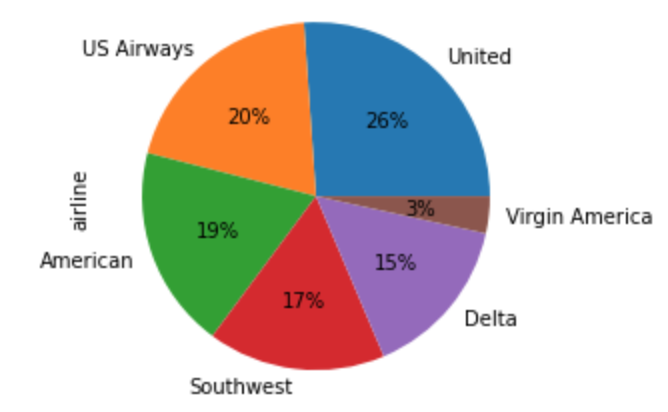

#### hints to above plot:
It is possible to access features from a dateframe as in one of several ways, e.g.:
1. dataframe.featurename
2. dataframe['featurename']
What about plotting?
To plot, we need to count features using value_counts and then call a plot function. 
....enough hints, go for it :-)


## Questions to answer from the plot above
- which airline had the most tweets?
- which airline had the fewest tweets?

## Task 5 - Distirubtion of sentiments
The tweets - are either negative, positive or neutral. 
Plot a pie chart that shows distribution of sentiments across the tweets.<br>
Your plot should look like below:<br>
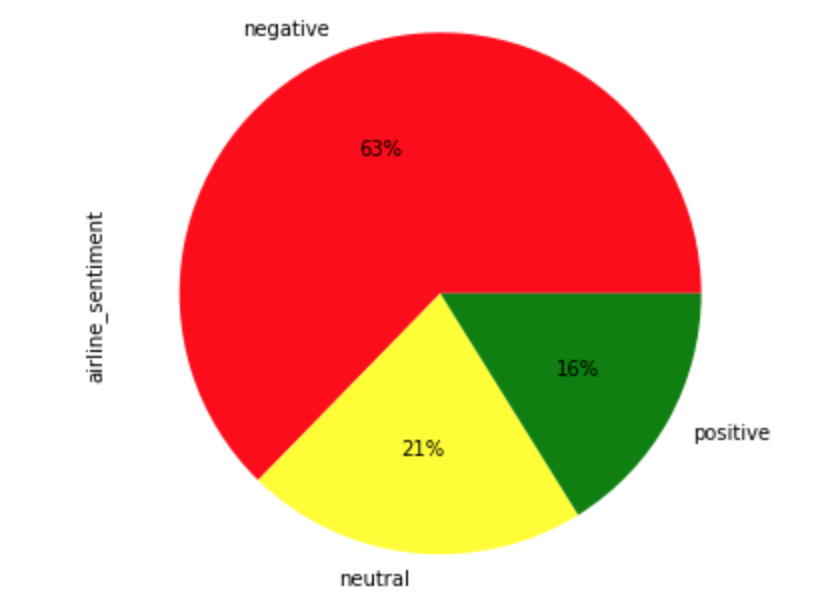



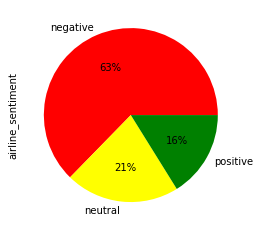

## Questions to consider:
What was the polarity of the most expressed sentiment?

## Task 6 - Distribution of sentiment by airline
We would like to see the distribution of sentments(positive, negative, neutral) across the airlines.
The best plot for this is a bar plot. Construct one; it should look like this: <br>
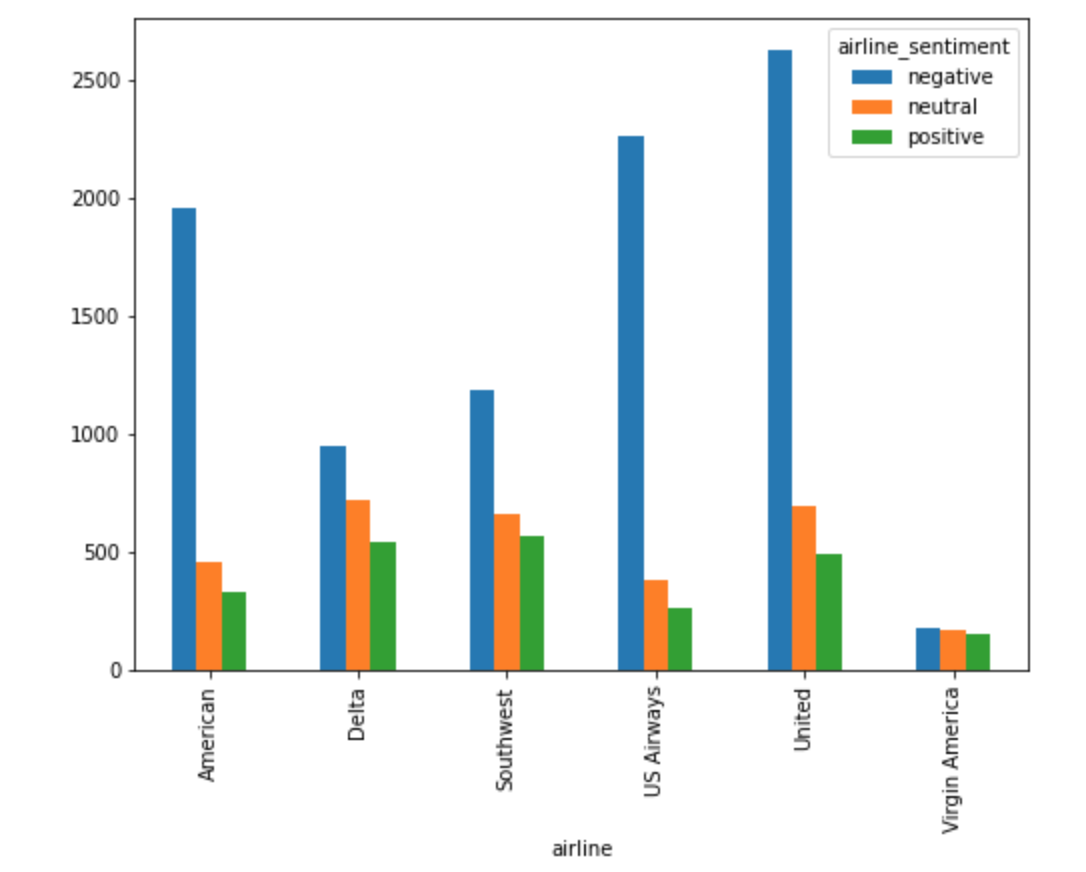

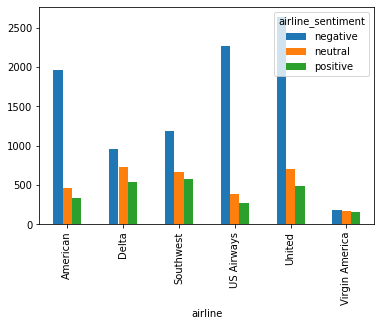

In [ ]:
airline_sentiment = airlines.groupby(['airline', 'airline_sentiment']).\
airline_sentiment.count().unstack()
airline_sentiment.plot(kind='bar');

### Answer these questions (informed by your plot):
- Which sentiment was consistently high for all the airlines?
- Which airline seems to have nearly a similar proportion of all the 3 sentiments?

## Task 7 - Creating feature and label sets
- Features - these are the tweets....in column 11
- Labels - these are the sentiments ..in the 2nd column
Create two variables - one called <b>features</b> and one <b>labels</b>
- Populate <b>features</b> variable with data from the tweets column. 
- Populate <b>labels</b> variable with data from sentiment column

Hint: You can use the `iloc` method of a pandas dataframe to specifify the exact column to obtain data from. Or you can use the method we used before


In [ ]:
features = airlines.iloc[:, 10].values
labels = airlines.iloc[:, 1].values

In [ ]:
features[0]

'@VirginAmerica What @dhepburn said.'

## Task 8 - Preprocessing
We need to  clean our `features` and remove things such as special characters, all single characters, substitute multiple spaces with a single space, etc <br>
Way forward: <br>
- create a new list, called `processed_features`.
- use a for or while loop to scan through the features
- use appropriate regular expressions to crean each feature as stated here (e.g., remove special characters, etc)
- finally, `append` your clean feature into the `processed_features` list

In [ ]:
processed_features = []

for sentence in range(0, len(features)):
    # Remove all the special characters
    processed_feature = re.sub(r'\W', ' ', str(features[sentence]))

    # remove all single characters
    processed_feature= re.sub(r'\s+[a-zA-Z]\s+', ' ', processed_feature)

    # Remove single characters from the start
    processed_feature = re.sub(r'\^[a-zA-Z]\s+', ' ', processed_feature) 

    # Substitute multiple spaces with single space
    processed_feature = re.sub(r'\s+', ' ', processed_feature, flags=re.I)

    # Removing prefixed 'b'
    processed_feature = re.sub(r'^b\s+', '', processed_feature)

    # Converting to Lowercase
    processed_feature = processed_feature.lower()

    processed_features.append(processed_feature)

## Task 9 - Some NLP review
Go through this summary of text preparation using nltk. <br> <br>
## Representing text as numbers
### Bag of words
Example, if we have the text: <br>
- Doc1 = "I like to play football"
- Doc2 = "It is a good game"
- Doc3 = "I prefer football over rugby"

1. First create a vocabulary of all unique words<br>
<b>Vocab</b>` = [I, like, to, play, football, it, is, a, good, game, prefer, over, rugby]` <br>
2. The next step is to convert each document into a feature vector using the vocabulary. <br>

The length of each feature vector is equal to the length of the vocabulary. The frequency of the word in the document will replace the actual word in the vocabulary. If a word in the vocabulary is not found in the corresponding document, the document feature vector will have zero in that place.<br>
<b>Example based on above documents</b>:
Doc1's Feature vector will be:<br> `[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]`

### TF-IDF (Term frequency and Inverse Document frequency)
With the bag of words approach, each word has the same weight.<br>
The idea behind the TF-IDF approach is that the <b>words that occur less</b> in all the documents and <b>more in individual an document</b> contribute more towards classification.

<b> TF  = (Frequency of a word in the document)/(Total words in the document) </b>

<b>IDF = Log((Total number of docs)/(Number of docs containing the word)) </b>

<em> We go for TF-IDF</em>


## import the Natural Language Processing Toolkit

In [ ]:
import nltk # StanfordParser
nltk.download('stopwords')
# A stop word -  commonly used word (e.g., “the”, “a”, “an”, “in”) that aren't consider useful in a corpus 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer (max_features=2500, min_df=7, max_df=0.8, stop_words=stopwords.words('english'))
processed_features = vectorizer.fit_transform(processed_features).toarray()

## What does the above cell do?
We define the <b>max_features</b> should be 2500. This  means that it only uses the 2500 most frequently occurring words to create a bag of words feature vector. Words that occur less frequently are not very useful for classification.

Also, <b>max_df</b> specifies that only use those words that occur in a maximum of 80% of the documents. Words that occur in all documents are too common and are not very useful for classification. Similarly, <b>min-df</b> is set to 7 which shows that include words that occur in at least 7 documents.

### Happy to proceed? Go to Task 10

## Task 10 - Training/Testing data splitting

We shall split our feature set and label set into training and testing arrays.<br>
We will use the train_test_split function from scikit-learn. Proceed as follows:<br>
1. import the train_test_split function
2. apply the function on your `processed_features` and `labels` and assign split arrays into variables x_train, x_test, y_train and y_test. Decide on your split ratio between training and test samples. Also, define `random_state` (give it an int value) parameter in the train_test_split function.



In [ ]:
# access train_test_split finction
#split features and labels
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(processed_features, labels, test_size = .2)

## Answer these questions:

- what is X_train? Check it's shape
- What is X_test? Check it's shape
- What are y_train and y_test? Check their shapes too
- What does test_size do?
- what does random_state parameter do?

In [ ]:
x_train.shape

(11712, 2301)

### Are we there yet? 
- Almost there :-)

## Task 11 - Train the model
We want to use the `RandomForestClassifier` algorithm. <br>
Import from `sklearn.ensemble` module.
1. Instantiate a classifier...give it a name r_classifier. Define paramets `n_estimators = 200 and random_state = 1`
2. Fit your model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
r_classifer = RandomForestClassifier(n_estimators=200)

In [ ]:
r_classifer.fit(x_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=200,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

## Task 12 - make predictions
Use the test dataset to make predictions
- check the accuracy prediction score against the validation set.<br>
<b> What is the accuracy score of your model?</b>



In [ ]:
classifications = r_classifer.predict(x_test)


In [1]:
#r_classifer.score(y_test, classifications)

## Bonus task
Let's create a confusion matrix using this line of code below.


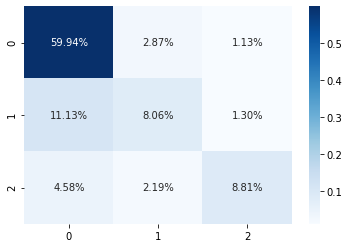

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cf_matrix = confusion_matrix(y_test,classifications)
import seaborn as sns
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%', cmap='Blues');

The matrix should like this<br>
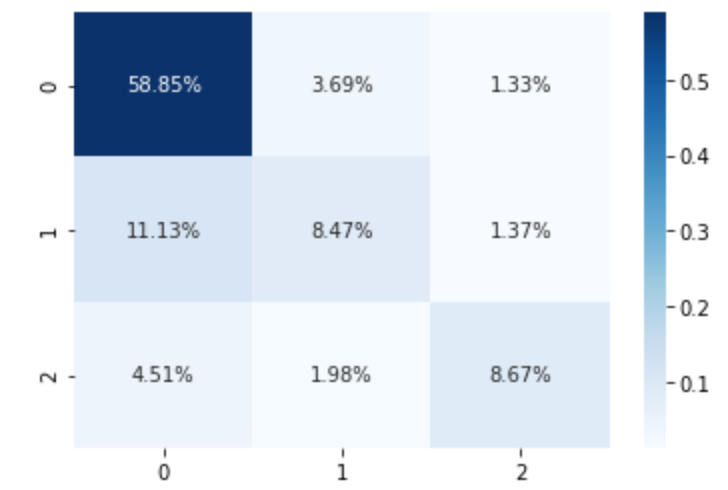

### Question - What does the confusion matrix tell us?

## Challenge
Try a naivebayes classifier on the same features and labels

## Defining Evaluation metrics
Most common ones are:<br>
1. <b>Mean Absolute Error (MAE)</b>-  is the mean of the absolute value of the errors: <br>
$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

Consider a simple dataset:<br>


In [ ]:
# define true and predicted response values
true = [100, 50, 30, 20]
pred = [90, 50, 50, 30]

## Compute MAE
...by hand <br>
... using inbuilt function

In [ ]:
# calculate MAE by hand
print((10 + 0 + 20 + 10)/4.)

# calculate MAE using scikit-learn
from sklearn import metrics
print(metrics.mean_absolute_error(true, pred))

10.0
10.0


2.**Mean Squared Error** (MSE) - the mean of the squared errors: <br>

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

In [ ]:

# Dataset here again
true = [100, 50, 30, 20]
pred = [90, 50, 50, 30]
# 2 clusters 
 # 2 centres 


# calculate MSE by hand
print((10**2 + 0**2 + 20**2 + 10**2)/4.)

# calculate MSE using scikit-learn
print(metrics.mean_squared_error(true, pred))

150.0
150.0


check one with largest distance
- clusteting, k-means

3. **Root Mean Squared Error** (RMSE) -  the square root of the mean of the squared errors: <br>

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

In [ ]:
# Dataset here again
true = [100, 50, 30, 20]
pred = [90, 50, 50, 30]


# calculate RMSE by hand
import numpy as np
print(np.sqrt((10**2 + 0**2 + 20**2 + 10**2)/4.))

# calculate RMSE using scikit-learn
print(np.sqrt(metrics.mean_squared_error(true, pred)))

12.24744871391589
12.24744871391589
